# Timing against the SVD
Time of the decomposition-free $\mathrm{Sgn}$ (generalized Newton–Schulz with the $\mathrm{bpoly}(D)$ profile, fixed $K_D$, power-iteration scaling) against the SVD-based one, over size $n$, $\sigma_{\min}$, device and $D$. Both routes get the same matrix; each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Each timing is paired with the relative Frobenius error against the exact $\mathrm{Sgn}(M)$. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.svd_timing import SvdTimingConfig, run_svd_timing, time_table, accuracy_table
%matplotlib inline

In [2]:
cfg = SvdTimingConfig(
    sizes=[128, 256, 512], smins=[1e-4], degrees=[1, 2, 3, 4],
    devices=["cpu", "cuda"], n_fixed=512, dtype=torch.float64, eps=None,
    power_iters=10, power_margin=1.1, n_warmup=3, n_reps=20, cpu_threads=None, svd_driver=None, seed=0,
)
res = run_svd_timing(cfg)

n=128 smin=0.0001: 20 matrices
  cpu: svd 1.80 ms | D=1 4.90 ms | D=2 4.76 ms | D=3 3.97 ms | D=4 4.68 ms
  cuda: svd 35.42 ms | D=1 7.70 ms | D=2 7.46 ms | D=3 7.77 ms | D=4 8.07 ms
n=256 smin=0.0001: 20 matrices
  cpu: svd 9.16 ms | D=1 17.80 ms | D=2 17.43 ms | D=3 17.62 ms | D=4 18.78 ms
  cuda: svd 203.62 ms | D=1 44.61 ms | D=2 44.06 ms | D=3 45.10 ms | D=4 48.70 ms
n=512 smin=0.0001: 20 matrices
  cpu: svd 42.08 ms | D=1 144.91 ms | D=2 140.20 ms | D=3 138.16 ms | D=4 148.04 ms
  cuda: svd 1271.38 ms | D=1 332.66 ms | D=2 327.15 ms | D=3 332.51 ms | D=4 362.74 ms


time (s), median ± std over 20 matrices: cpu, smin = 0.0001
n    D=1              D=2               D=3                D=4              SVD              
128  0.0049 ± 0.0012  0.00476 ± 0.0015  0.00397 ± 0.00074  0.00468 ± 0.02   0.0018 ± 0.0003  
256  0.0178 ± 0.0025  0.0174 ± 0.0086   0.0176 ± 0.0076    0.0188 ± 0.0019  0.00916 ± 0.00065
512  0.145 ± 0.04     0.14 ± 0.037      0.138 ± 0.046      0.148 ± 0.048    0.0421 ± 0.0079  

relative Frobenius error, mean ± std over 20 matrices, and iterations run K: cpu, smin = 0.0001
     K   n=128               n=256               n=512             
D=1  32  1.11e-13 ± 7.0e-15  1.42e-13 ± 2.9e-15  1.34e-13 ± 1.7e-15
D=2  21  9.48e-14 ± 4.5e-15  1.20e-13 ± 2.9e-15  1.17e-13 ± 1.4e-15
D=3  16  8.99e-14 ± 4.4e-15  1.12e-13 ± 2.3e-15  1.11e-13 ± 1.6e-15
D=4  14  8.61e-14 ± 3.8e-15  1.05e-13 ± 2.7e-15  1.07e-13 ± 1.6e-15
SVD  -   0.00e+00 ± 0.0e+00  0.00e+00 ± 0.0e+00  0.00e+00 ± 0.0e+00

time (s), median ± std over 20 matrices: cuda, smin = 0.00

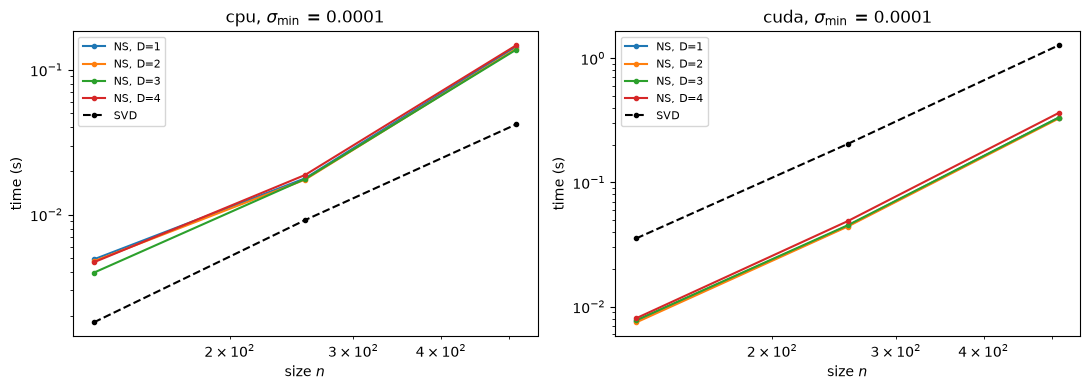

In [3]:
smin_plot = 1e-4  # sigma_min shown in the time-vs-size panels and the tables
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, smin_plot, ax=ax)
fig.tight_layout()
for device in res["cfg"].devices:
    time_table(res, device, smin_plot)
    print()
    accuracy_table(res, device, smin_plot)
    print()

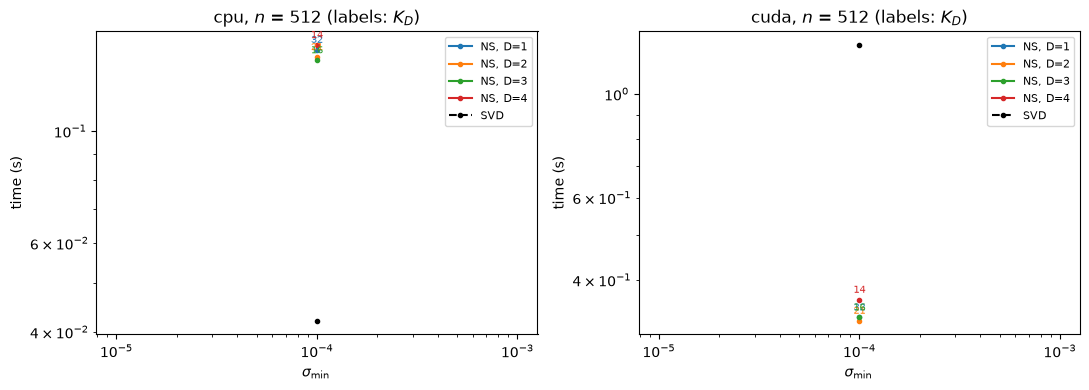

In [4]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_smin(res, device, ax=ax)
fig.tight_layout()